# Import Libraries and Dependences

In [47]:
import rasterio
import rasterio.mask
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os
from shapely.geometry import box
from rasterio.warp import reproject, Resampling

rio_mask = rasterio.mask.mask 
print(type(rio_mask))  

<class 'function'>


In [49]:
center_x = -1_900_000
center_y =  1_800_000
half_size =   200_000

sierra_box = box(
    center_x - half_size,
    center_y - half_size,
    center_x + half_size,
    center_y + half_size
)

sierra_gdf = gpd.GeoDataFrame(geometry=[sierra_box], crs="EPSG:5070")
sierra_geom = [sierra_gdf.geometry.values[0]]
print("Sierra box defined")

Sierra box defined


In [50]:
files = {
    'Fuel (Scott-Burgan 40)':r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\RAW\LF2024_FBFM40_CONUS.tif",
    "Slope" :r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\RAW\LF2020_SlpD_CONUS.tif",
    "Aspect" :r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\RAW\LF2020_Asp_CONUS.tif",
    "Elevation" :r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\RAW\LF2020_Elev_CONUS.tif"

}

for name, path in files.items():
    with rasterio.open(path) as src:
        print(f'{name}')
        print(f'CRS {src.crs}')
        print(f'Resolution {src.res}')
        print(f'Shape {src.width} x {src.height}')
        print(f'Bounds {src.bounds}')
        print('\n')

Fuel (Scott-Burgan 40)
CRS EPSG:5070
Resolution (30.0, 30.0)
Shape 156336 x 101538
Bounds BoundingBox(left=-2362425.0, bottom=221265.0, right=2327655.0, top=3267405.0)


Slope
CRS EPSG:5070
Resolution (30.0, 30.0)
Shape 156336 x 101538
Bounds BoundingBox(left=-2362425.0, bottom=221265.0, right=2327655.0, top=3267405.0)


Aspect
CRS EPSG:5070
Resolution (30.0, 30.0)
Shape 156336 x 101538
Bounds BoundingBox(left=-2362425.0, bottom=221265.0, right=2327655.0, top=3267405.0)


Elevation
CRS EPSG:5070
Resolution (30.0, 30.0)
Shape 156336 x 101538
Bounds BoundingBox(left=-2362425.0, bottom=221265.0, right=2327655.0, top=3267405.0)




# Scaling down to the Sierra Nevada Region

In [51]:
os.makedirs(r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\PROCESSED", exist_ok=True)

TARGET_RES = 3000  # metres

files = {
    "Fuel":      (r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\RAW\LF2024_FBFM40_CONUS.tif",
                  r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\PROCESSED\fuel_sierra.tif"),
    "Slope":     (r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\RAW\LF2020_SlpD_CONUS.tif",
                  r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\PROCESSED\slope_sierra.tif"),
    "Aspect":    (r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\RAW\LF2020_Asp_CONUS.tif",
                  r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\PROCESSED\aspect_sierra.tif"),
    "Elevation": (r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\RAW\LF2020_Elev_CONUS.tif",
                  r"C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\PROCESSED\elevation_sierra.tif"),
}

for name, (src_path, dst_path) in files.items():
    print(f"Processing {name}...")
    with rasterio.open(src_path) as src:

        clipped, clipped_transform = rio_mask(src, sierra_geom, crop=True)
        clipped_meta = src.meta.copy()
        clipped_meta.update({
            "height": clipped.shape[1],
            "width":  clipped.shape[2],
            "transform": clipped_transform
        })

        scale_factor = TARGET_RES / 30
        new_h = int(clipped.shape[1] / scale_factor)
        new_w = int(clipped.shape[2] / scale_factor)

        resampling_method = Resampling.nearest if name == "Fuel" else Resampling.bilinear
        resampled = np.empty((clipped.shape[0], new_h, new_w), dtype=clipped.dtype)
        new_transform = clipped_transform * clipped_transform.scale(scale_factor, scale_factor)

        reproject(
            source=clipped,
            destination=resampled,
            src_transform=clipped_transform,
            src_crs=src.crs,
            dst_transform=new_transform,
            dst_crs=src.crs,
            resampling=resampling_method
        )

        clipped_meta.update({"height": new_h, "width": new_w, "transform": new_transform})

        with rasterio.open(dst_path, "w", **clipped_meta) as dst:
            dst.write(resampled)

    print(f"Saved: {dst_path}")

Processing Fuel...
  ✓ Saved: C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\PROCESSED\fuel_sierra.tif
Processing Slope...
  ✓ Saved: C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\PROCESSED\slope_sierra.tif
Processing Aspect...
  ✓ Saved: C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\PROCESSED\aspect_sierra.tif
Processing Elevation...
  ✓ Saved: C:\Users\peter\Documents\ANGLIA\MACHINE LEARNING\PROJECT\RL\DATA\PROCESSED\elevation_sierra.tif


In [52]:
for name, (_, dst_path) in files.items():
    with rasterio.open(dst_path) as src:
        print(f"{name}: {src.width} x {src.height}")

Fuel: 133 x 133
Slope: 133 x 133
Aspect: 133 x 133
Elevation: 133 x 133


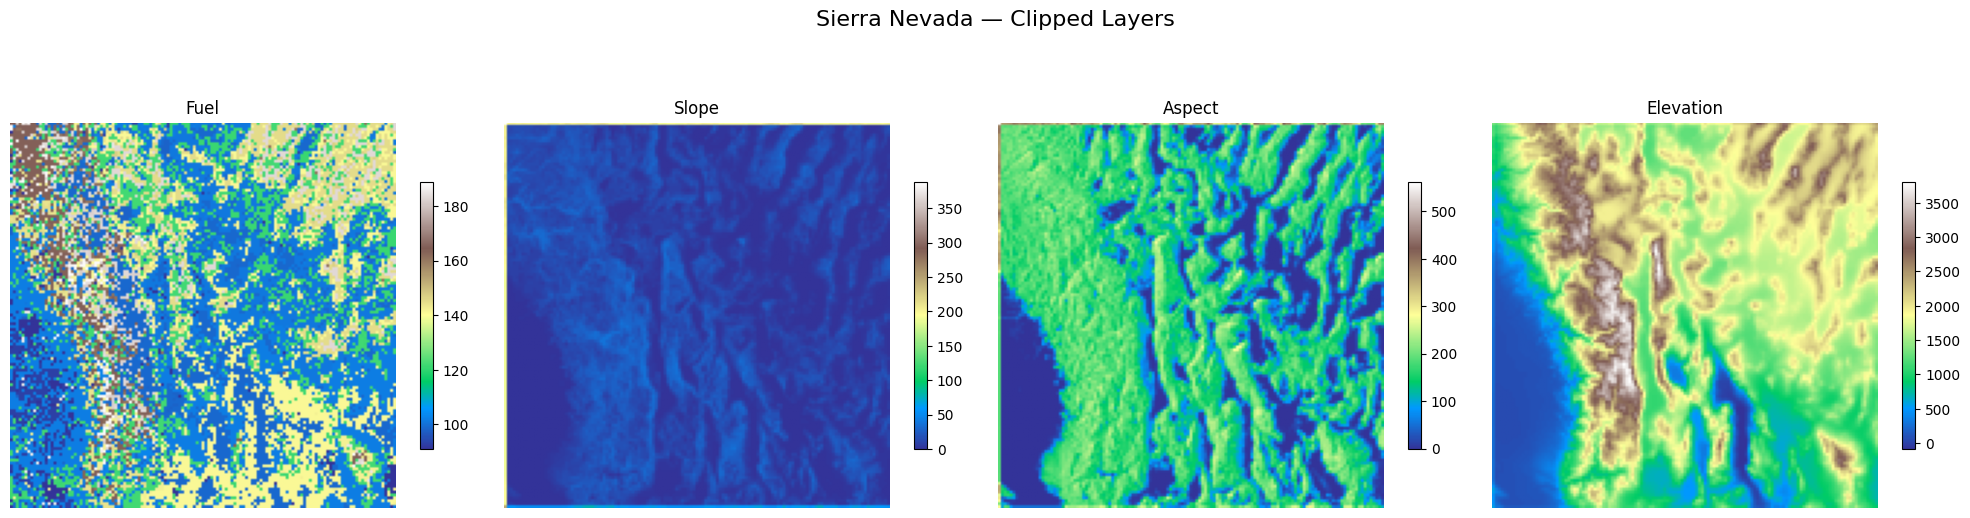

In [53]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for ax, (name, (_, path)) in zip(axes, files.items()):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
        data[data == -9999] = np.nan

    im = ax.imshow(data, cmap="terrain")
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(im, ax=ax, shrink=0.5)

plt.suptitle("Sierra Nevada — Clipped Layers", fontsize=16)
plt.tight_layout()
plt.show()